# Exercice 1 - Découvrez les blocs de construction de l'Apprentissage par Renforcement

Pour cet exercice, j'ai utilisé l'exemple de base de la documentation officielle de Gymnasium (Basic Usage) afin d'illustrer le cycle d'interaction entre un agent et son environnement via le projet CartPole-v1. https://gymnasium.farama.org/introduction/basic_usage/

## Expérience du CartPole

Le **but de l'expérience CartPole** (aussi appelé problème du pendule inversé) est un classique en apprentissage par renforcement et contrôle optimal. Il s'agit de :

### But de l'expérience
**Maintenir un mât vertical en équilibre sur un chariot mobile en appliquant des forces à gauche ou à droite sur le chariot.**

## But de l'exercice

L'objectif de cet exercice est de se familiariser avec les concepts fondamentaux de l'Apprentissage par Renforcement (RL) et l'interface **Gymnasium**. Il s'agit de :

*   **Maîtriser le cycle d'interaction** : Comprendre la boucle entre l'agent et l'environnement (Observation → Action → Récompense).
*   **Explorer les espaces de données** : Identifier la structure des observations (états du système) et des actions possibles.
*   **Se familiariser avec les outils et méthodes** : Apprendre à manipuler les fonctions standards (reset, step, render) et les méthodes d'exploration comme .sample().


Espace d'observation : Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Espace d'action : Discrete(2)

Exemple d'observation aléatoire : [ 2.281301   -0.29359668 -0.20106594 -0.9708295 ]
Exemple d'action aléatoire : 1
Épisode 1 : Récompense totale = 17.0
Épisode 2 : Récompense totale = 13.0
Épisode 3 : Récompense totale = 21.0


/usr/local/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Épisode 4 : Récompense totale = 42.0
Épisode 5 : Récompense totale = 16.0
Épisode 6 : Récompense totale = 19.0
Épisode 7 : Récompense totale = 14.0
Épisode 8 : Récompense totale = 12.0
Épisode 9 : Récompense totale = 17.0
Épisode 10 : Récompense totale = 46.0


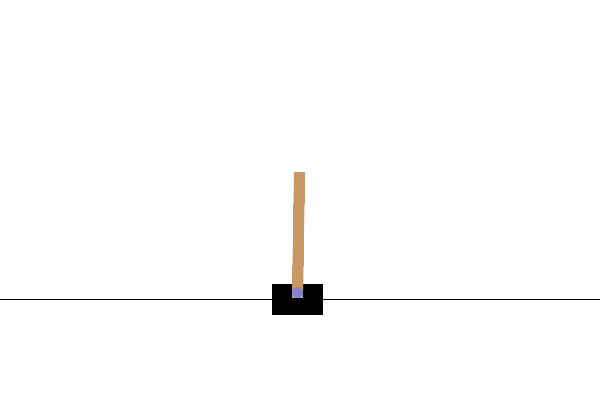

In [1]:
import gymnasium as gym
import imageio
from IPython.display import Image, display
from PIL import Image as PILImage, ImageDraw
import numpy as np

# Créer l'environnement
env = gym.make("CartPole-v1", render_mode="rgb_array")

# Afficher les espaces d'observation et d'action
print("Espace d'observation :", env.observation_space)
print("Espace d'action :", env.action_space)

# Afficher un échantillon aléatoire d'observation et d'action
print("\nExemple d'observation aléatoire :", env.observation_space.sample())
print("Exemple d'action aléatoire :", env.action_space.sample())

frames = []
gif_path = "cartpole_with_steps.gif"

def add_text_to_frame(frame, step):
    img = PILImage.fromarray(frame)
    draw = ImageDraw.Draw(img)
    draw.text((10, 10), f"Step: {step}", fill=(255, 255, 255))
    return np.array(img)

for episode in range(10):
    observation, info = env.reset()
    episode_over = False
    step_number = 0
    total_reward = 0

    while not episode_over:
        frame = env.render()

        # On enregistre les images SEULEMENT pour le dernier épisode
        if episode == 9:
            frames.append(add_text_to_frame(frame, step_number))

        action = env.action_space.sample()
        observation, reward, terminated, truncated, info = env.step(action)
        episode_over = terminated or truncated
        total_reward += reward
        step_number += 1

    print(f"Épisode {episode + 1} : Récompense totale = {total_reward}")

env.close()

# Sauvegarder et afficher le GIF
if frames:
    imageio.mimsave(gif_path, frames, fps=10, loop=0)
    display(Image(filename=gif_path))

## Bilan d'observation

L'environnement CartPole-v1 repose sur deux structures clés :

* Espace d'**observation (Box)** : Un espace **continu** composé de 4 variables (position et vitesse du chariot, angle et vitesse angulaire du mât) permettant à l'agent de percevoir l'état précis du système.
* Espace d'**action (Discrete)** : Un espace binaire simple (**discret**) où l'agent n'a que deux choix possibles à chaque étape : pousser le chariot vers la gauche (0) ou vers la droite (1).
* Objectif et Récompense : L'agent reçoit +1 point par étape tant que le mât reste debout. L'épisode s'arrête si l'angle dépasse ~12° ou si le chariot sort des limites latérales.
* Performance Aléatoire : L'utilisation de .sample() démontre qu'une stratégie aléatoire est insuffisante pour stabiliser le système, avec une survie moyenne très courte (souvent inférieure à 20 étapes).